In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import seaborn as sns
import os

In [3]:
from analysis.utils import load_sweep_metadata, load_data
from analysis.utils_decoding import evaluate_lags_leave_k_out

In [4]:
def compute_success(df_data,
                    threshold_angle=0.1,
                    consecutive_steps=100,
                    starting_step=0,
                    column_name=None):
    """
    Compute whether the pole is upright (straight) for consecutive_steps time points.
    
    Args:
        df_data: DataFrame with 'observations' column containing state arrays
        threshold_angle: Maximum angle deviation from vertical (in radians) to consider "straight"
        consecutive_steps: Number of consecutive steps required for success
    
    Returns:
        df_data: DataFrame with added 'success' column and 'percentage_straight' column
    """
    success = []
    percentage_straight = []

    for idx in range(len(df_data)):
        observations = np.array(df_data['observations'].iloc[idx])
        observations = observations[starting_step:]

        # Extract cos and sin of pole angle (dimensions 1 and 2)
        cos_angle = observations[:, 1]
        sin_angle = observations[:, 2]

        # Compute actual angle from cos and sin
        angles = np.arctan2(sin_angle, cos_angle)

        # Check if angle is within threshold (close to 0, which is upright)
        is_straight = np.abs(angles) < threshold_angle

        # Compute percentage of steps with pole straight
        pct_straight = np.sum(is_straight) / len(is_straight) * 100
        percentage_straight.append(pct_straight)

        # Check for consecutive_steps consecutive True values
        episode_success = False
        count = 0
        for straight in is_straight:
            if straight:
                count += 1
                if count >= consecutive_steps:
                    episode_success = True
                    break
            else:
                count = 0

        success.append(episode_success)
    column_name = column_name if column_name is not None else 'success'
    df_data[column_name] = np.array(success)
    df_data['percentage_straight'] = np.array(percentage_straight)
    return df_data


def chunk_data(data, chunk_size=500):
    return [data[i:i + chunk_size] for i in range(0, len(data), chunk_size)]


## Load tdmpc2 data

In [5]:
df_metadata_tdmpc2 = load_sweep_metadata([
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep"
],
                                         json_file_name='episode_metadata.json')
df_metadata_tdmpc2 = df_metadata_tdmpc2[df_metadata_tdmpc2['model_step'] ==
                                        500_000]

df_metadata_tdmpc2 = df_metadata_tdmpc2[df_metadata_tdmpc2['seed'] == 1]

df_tdmpc2 = load_data(
    df_metadata_tdmpc2,
    episode_file_name='episode_data.pkl',
    #cart_position=0.,
)

df_tdmpc2.shape

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep:   0%|          | 0/108 [00:00<?, ?it/s]

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████| 108/108 [00:00<00:00, 8608.44it/s]


Found 108 configurations
Found 18 configurations


100%|██████████| 18/18 [00:00<00:00, 27.29it/s]


(18, 17)

In [6]:
df_tdmpc2['initial_state_cart_position'] = df_tdmpc2['initial_state'].apply(
    lambda x: x[0])
df_tdmpc2['initial_state_pole_angle_rad'] = df_tdmpc2['initial_state'].apply(
    lambda x: x[1])
df_tdmpc2['initial_state_pole_angle_deg'] = np.degrees(
    df_tdmpc2['initial_state_pole_angle_rad'])


## Load sac data

In [7]:
df_metadata_sac = load_sweep_metadata([
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/pytorch_sac/logs/25-01-09-cartpole_initial_conditions_seeds_sweep"
],
                                      json_file_name='episode_0000_metadata.json'
                                     )

df_metadata_sac = df_metadata_sac[df_metadata_sac['seed'] == 1]

df_metadata_sac = df_metadata_sac[
    df_metadata_sac['initial_state_cart_position'].isin([-1, 0, 1])]

df_sac = load_data(
    df_metadata_sac,
    episode_file_name='episode_0000.pkl',
    #cart_position=0.,
)

df_sac['total_reward'] = df_sac['total_reward'] * 2

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/pytorch_sac/logs/25-01-09-cartpole_initial_conditions_seeds_sweep: 100%|██████████| 275/275 [00:00<00:00, 1470.74it/s]


Found 275 configurations
Found 33 configurations


100%|██████████| 33/33 [00:00<00:00, 135.16it/s]


In [8]:
## For the sake of comparison, only take the rows that have same angle

# Find common angles between SAC and TDMPC2
common_angles = set(df_sac['initial_state_pole_angle_deg'].unique()) & set(
    df_tdmpc2['initial_state_pole_angle_deg'].unique())

# Remove 0 and 360 degrees
common_angles = common_angles - {0, 360}

print(f"Common angles: {sorted(common_angles)}")

# Filter both dataframes to only include common angles
df_sac = df_sac[df_sac['initial_state_pole_angle_deg'].isin(common_angles)]
df_tdmpc2 = df_tdmpc2[df_tdmpc2['initial_state_pole_angle_deg'].isin(
    common_angles)]

print(f"SAC shape after filtering: {df_sac.shape}")
print(f"TDMPC2 shape after filtering: {df_tdmpc2.shape}")


Common angles: [72.0, 144.0, 216.0, 288.0]
SAC shape after filtering: (12, 20)
TDMPC2 shape after filtering: (12, 20)


In [9]:
df_sac = compute_success(df_sac, threshold_angle=0.1)
df_tdmpc2 = compute_success(df_tdmpc2, threshold_angle=0.1)

## Compare tdmpc2 and sac data in terms of success/reward

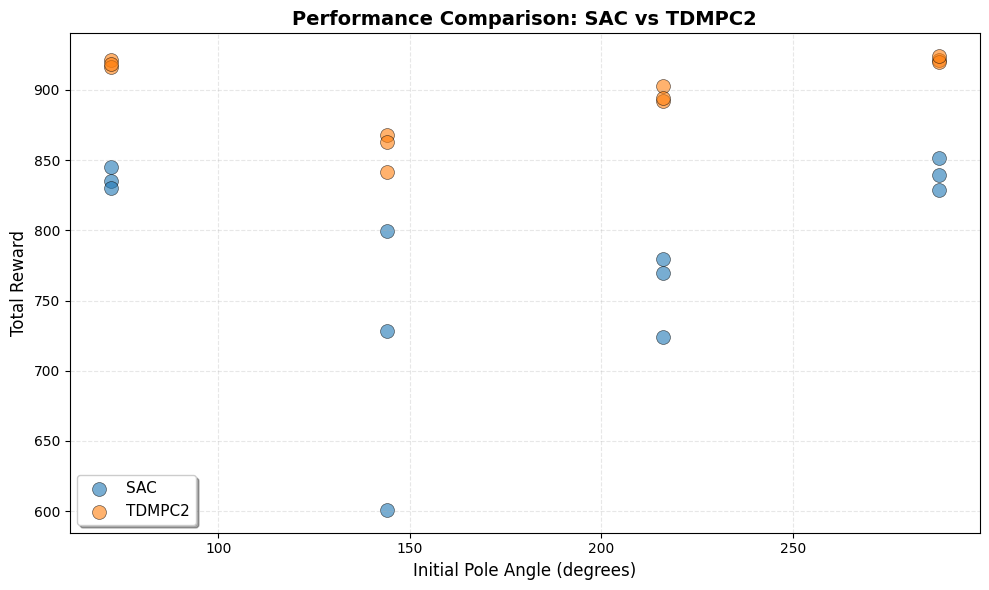

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot SAC data
ax.scatter(df_sac['initial_state_pole_angle_deg'],
           df_sac['total_reward'],
           label='SAC',
           alpha=0.6,
           s=100,
           edgecolors='black',
           linewidth=0.5)

# Plot TDMPC2 data
ax.scatter(df_tdmpc2['initial_state_pole_angle_deg'],
           df_tdmpc2['total_reward'],
           label='TDMPC2',
           alpha=0.6,
           s=100,
           edgecolors='black',
           linewidth=0.5)

ax.set_xlabel('Initial Pole Angle (degrees)', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Performance Comparison: SAC vs TDMPC2',
             fontsize=14,
             fontweight='bold')
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

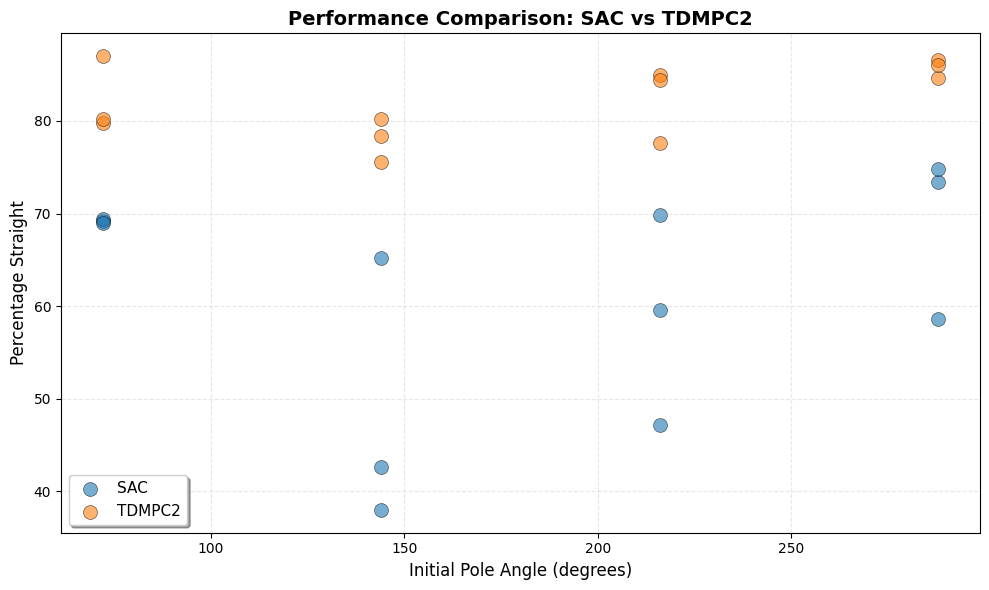

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot SAC data
ax.scatter(df_sac['initial_state_pole_angle_deg'],
           df_sac['percentage_straight'],
           label='SAC',
           alpha=0.6,
           s=100,
           edgecolors='black',
           linewidth=0.5)

# Plot TDMPC2 data
ax.scatter(df_tdmpc2['initial_state_pole_angle_deg'],
           df_tdmpc2['percentage_straight'],
           label='TDMPC2',
           alpha=0.6,
           s=100,
           edgecolors='black',
           linewidth=0.5)

ax.set_xlabel('Initial Pole Angle (degrees)', fontsize=12)
ax.set_ylabel('Percentage Straight', fontsize=12)
ax.set_title('Performance Comparison: SAC vs TDMPC2',
             fontsize=14,
             fontweight='bold')
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

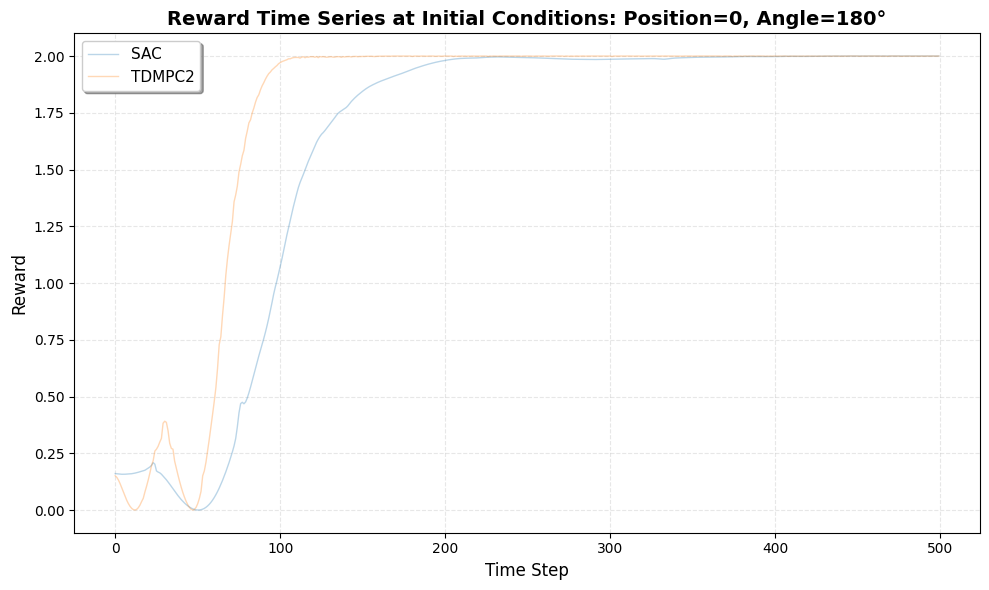

SAC episodes: 1, Mean total reward: 799.89
TDMPC2 episodes: 1, Mean total reward: 868.03


In [12]:
# Filter for initial conditions: cart position = 0, pole angle = 180 degrees
sac_180 = df_sac[(df_sac['initial_state_cart_position'] == 0) &
                 (df_sac['initial_state_pole_angle_deg'] == 144)]
tdmpc2_180 = df_tdmpc2[(df_tdmpc2['initial_state_cart_position'] == 0) &
                       (df_tdmpc2['initial_state_pole_angle_deg'] == 144)]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot SAC rewards as time series
for idx, row in sac_180.iterrows():
    rewards = row['rewards'] * 2
    ax.plot(range(len(rewards)),
            rewards,
            label='SAC' if idx == sac_180.index[0] else '',
            alpha=0.3,
            linewidth=1)

# Plot TDMPC2 rewards as time series
for idx, row in tdmpc2_180.iterrows():
    rewards = row['rewards']
    ax.plot(range(len(rewards)),
            rewards,
            label='TDMPC2' if idx == tdmpc2_180.index[0] else '',
            alpha=0.3,
            linewidth=1)

ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title('Reward Time Series at Initial Conditions: Position=0, Angle=180°',
             fontsize=14,
             fontweight='bold')
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(
    f"SAC episodes: {len(sac_180)}, Mean total reward: {sac_180['total_reward'].mean():.2f}"
)
print(
    f"TDMPC2 episodes: {len(tdmpc2_180)}, Mean total reward: {tdmpc2_180['total_reward'].mean():.2f}"
)


## Decoding 

In [13]:
df_sac['actor_h1'] = df_sac['hidden_activations'].apply(lambda x: x['actor_h1'])
df_sac['actor_h2'] = df_sac['hidden_activations'].apply(lambda x: x['actor_h2'])
z_h2 = np.concatenate(df_sac['actor_h2'].tolist(), axis=0).squeeze()
z_h1 = np.concatenate(df_sac['actor_h1'].tolist(), axis=0).squeeze()
z_sac = np.hstack([z_h2, z_h1]).squeeze()
z_sac.shape

(6000, 2048)

In [14]:
vars_sac = {
    'z':
        z_h2,
    'obs':
        np.concatenate(df_sac['observations'].tolist()),
    'position':
        np.concatenate(df_sac['observations'].tolist())[:, 0].reshape(-1, 1),
    'cos(pole_angle)':
        np.concatenate(df_sac['observations'].tolist())[:, 1].reshape(-1, 1),
    'sin(pole_angle)':
        np.concatenate(df_sac['observations'].tolist())[:, 2].reshape(-1, 1),
    'cart_velocity':
        np.concatenate(df_sac['observations'].tolist())[:, 3].reshape(-1, 1),
    'pole_angular_velocity':
        np.concatenate(df_sac['observations'].tolist())[:, 4].reshape(-1, 1),
    'rewards':
        np.concatenate(df_sac['rewards'].tolist()).reshape(-1, 1),
    'actions':
        np.concatenate(df_sac['actions'].tolist()),
}

for key, value in vars_sac.items():
    print(f"{key}: {value.shape}")

vars_tdmpc2 = {
    'z':
        np.concatenate(df_tdmpc2['latent_states'].tolist()),
    'obs':
        np.concatenate(df_tdmpc2['observations'].tolist()),
    'position':
        np.concatenate(df_tdmpc2['observations'].tolist())[:, 0].reshape(-1, 1),
    'cos(pole_angle)':
        np.concatenate(df_tdmpc2['observations'].tolist())[:, 1].reshape(-1, 1),
    'sin(pole_angle)':
        np.concatenate(df_tdmpc2['observations'].tolist())[:, 2].reshape(-1, 1),
    'cart_velocity':
        np.concatenate(df_tdmpc2['observations'].tolist())[:, 3].reshape(-1, 1),
    'pole_angular_velocity':
        np.concatenate(df_tdmpc2['observations'].tolist())[:, 4].reshape(-1, 1),
    'rewards':
        np.concatenate(df_tdmpc2['rewards'].tolist()).reshape(-1, 1),
    'actions':
        np.concatenate(df_tdmpc2['actions'].tolist()),
}

for key, value in vars_tdmpc2.items():
    print(f"{key}: {value.shape}")

z: (6000, 1024)
obs: (6000, 5)
position: (6000, 1)
cos(pole_angle): (6000, 1)
sin(pole_angle): (6000, 1)
cart_velocity: (6000, 1)
pole_angular_velocity: (6000, 1)
rewards: (6000, 1)
actions: (6000, 1)
z: (6000, 512)
obs: (6000, 5)
position: (6000, 1)
cos(pole_angle): (6000, 1)
sin(pole_angle): (6000, 1)
cart_velocity: (6000, 1)
pole_angular_velocity: (6000, 1)
rewards: (6000, 1)
actions: (6000, 1)


In [15]:
all_combs = [
    ('z', 'obs'),
    ('z', 'position'),
    ('z', 'cos(pole_angle)'),
    ('z', 'sin(pole_angle)'),
    ('z', 'cart_velocity'),
    ('z', 'pole_angular_velocity'),
    ('z', 'rewards'),
    ('z', 'actions'),
    ('obs', 'obs'),
    ('position', 'position'),
    ('cos(pole_angle)', 'cos(pole_angle)'),
    ('sin(pole_angle)', 'sin(pole_angle)'),
    ('cart_velocity', 'cart_velocity'),
    ('pole_angular_velocity', 'pole_angular_velocity'),
    ('rewards', 'rewards'),
    ('actions', 'actions'),
]


In [ ]:
path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2'
#path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/pytorch_sac/analysis/'

for vars_key, vars in {'sac': vars_sac, 'tdmpc2': vars_tdmpc2}.items():
    for predict_type in ['difference', 'future']:
        results_decoding = {}
        for x_var, y_var in all_combs:
            print(f"Decoding {x_var} -> {y_var}")
            results_decoding[f'{x_var}-{y_var}'] = evaluate_lags_leave_k_out(
                chunk_data(vars[x_var], chunk_size=500),
                chunk_data(vars[y_var], chunk_size=500),
                model='linear_regression',
                lags=np.arange(-80, 81, 10),
                k_holdout=1,
                add_bootstrap_ci=True,
                shuffle_X=False,
                shuffle_y=False,
                predict_difference=True
                if predict_type == 'difference' else False)

        #Save results_decoding to pickle file
        with open(
                os.path.join(
                    path_to_save,
                    f'results_decoding_lr_{predict_type}_{vars_key}_onlyswingupangles.pkl'
                ), 'wb') as f:
            pickle.dump(results_decoding, f)

## Load results 

In [29]:
path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2'


def load_decoding_results(path_to_save, model_type, predict_type, vars_key):
    """Load decoding results from pickle file.
    
    Args:
        path_to_save: Base path where results are saved
        model_type: Type of model ('lr' or 'lasso')
        predict_type: Type of prediction ('difference' or 'future')
        vars_key: Variable key ('sac' or 'tdmpc2')
    
    Returns:
        Loaded results dictionary
    """
    filename = f'results_decoding_{model_type}_{predict_type}_{vars_key}_onlyswingupangles.pkl'
    with open(os.path.join(path_to_save, filename), 'rb') as f:
        return pickle.load(f)


# Load SAC results
results_decoding_lr_sac_difference = load_decoding_results(
    path_to_save, 'lr', 'difference', 'sac')

results_decoding_lr_sac_future = load_decoding_results(path_to_save, 'lr',
                                                       'future', 'sac')

results_decoding_lasso_sac_difference = load_decoding_results(
    path_to_save, 'lasso', 'difference', 'sac')

results_decoding_lasso_sac_future = load_decoding_results(
    path_to_save, 'lr', 'future', 'sac')

# Load TDMPC2 results
results_decoding_lr_tdmpc2_difference = load_decoding_results(
    path_to_save, 'lr', 'difference', 'tdmpc2')

results_decoding_lr_tdmpc2_future = load_decoding_results(
    path_to_save, 'lr', 'future', 'tdmpc2')

results_decoding_lasso_tdmpc2_difference = load_decoding_results(
    path_to_save, 'lasso', 'difference', 'tdmpc2')

results_decoding_lasso_tdmpc2_future = load_decoding_results(
    path_to_save, 'lasso', 'future', 'tdmpc2')


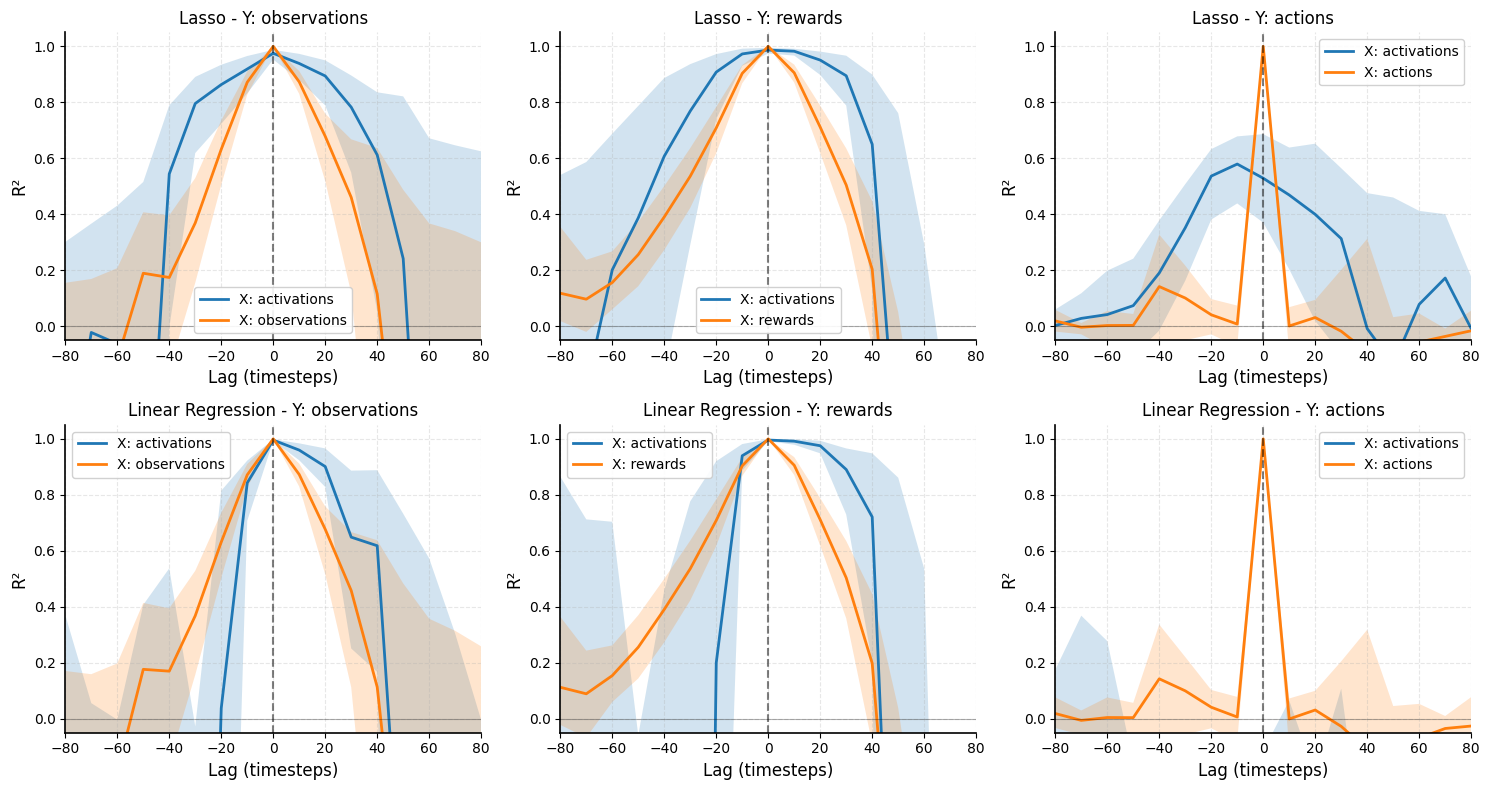

In [36]:
plot_dict = {
    0: ['z-obs', 'obs-obs'],
    1: ['z-rewards', 'rewards-rewards'],
    2: ['z-actions', 'actions-actions']
}

map_dict = {
    'z': 'activations',
    'obs': 'observations',
    'rewards': 'rewards',
    'actions': 'actions'
}

# Choose which model to plot: 'sac' or 'tdmpc2'
model_to_plot = 'tdmpc2'

# Create a figure with 2 rows (lasso, lr) and as many columns as keys in plot_dict
num_plots = len(plot_dict)
fig, axes = plt.subplots(2, num_plots, figsize=(15, 8))

# Iterate through plot_dict
for plot_idx, key_list in plot_dict.items():
    # First row: Lasso
    ax_lasso = axes[0, plot_idx]
    # Second row: Linear Regression
    ax_lr = axes[1, plot_idx]

    # Select the appropriate results based on model_to_plot
    if model_to_plot == 'sac':
        results_lasso = results_decoding_lasso_sac_future
        results_lr = results_decoding_lr_sac_future
    else:  # tdmpc2
        results_lasso = results_decoding_lasso_tdmpc2_future
        results_lr = results_decoding_lr_tdmpc2_future

    # Plot for both lasso and lr
    for ax, results_dict, model_name in [(ax_lasso, results_lasso, 'Lasso'),
                                         (ax_lr, results_lr,
                                          'Linear Regression')]:
        # Plot each key in the list for this subplot
        for key in key_list:
            if key in results_dict:
                results = results_dict[key]

                r2_mean = results['r2_mean']
                r2_ci = results['r2_ci']

                # Extract lags and R² values from the dictionary
                lags = list(r2_mean.keys())
                means = list(r2_mean.values())

                # r2_ci is a tuple of (lower_dict, upper_dict)
                ci_lower = [r2_ci[lag][0] for lag in lags]
                ci_upper = [r2_ci[lag][1] for lag in lags]

                # Plot with label based on the key
                title = key.split('-')
                label = f'X: {map_dict[title[0]]}'
                ax.plot(lags, means, label=label, linewidth=2)
                ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2)

        ax.set_xlabel('Lag (timesteps)', fontsize=12)
        ax.set_ylabel('R²', fontsize=12)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
        ax.legend(fontsize=10, framealpha=0.9)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlim(-80, 80)
        ax.tick_params(labelsize=10)
        ax.set_title(f'{model_name} - Y: {map_dict[title[1]]}')
        # Add spines styling
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

#plt.suptitle(f'Decoding Analysis - {model_to_plot.upper()}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
sns.despine()
plt.show()

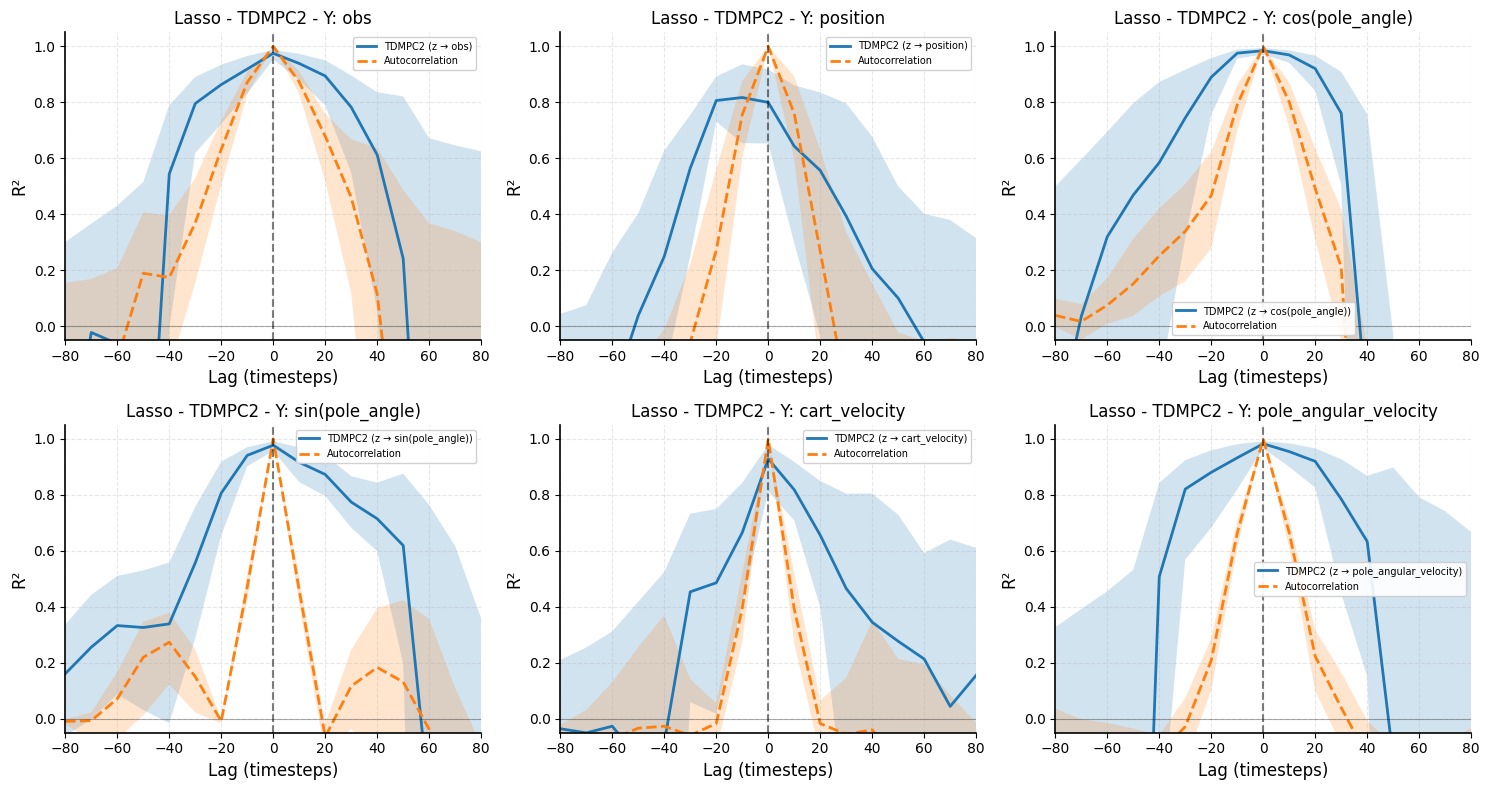

In [66]:
# Create plots comparing SAC vs TDMPC2 for future prediction
plot_keys = [
    ('z', 'obs'),
    ('z', 'position'),
    ('z', 'cos(pole_angle)'),
    ('z', 'sin(pole_angle)'),
    ('z', 'cart_velocity'),
    ('z', 'pole_angular_velocity'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Choose which regression method to use
use_lasso = True  # Set to False for Linear Regression

# Choose which model to plot
model_to_plot = 'tdmpc2'  # 'tdmpc2' or 'sac'

for idx, (x_var, y_var) in enumerate(plot_keys):
    ax = axes[idx]
    key = f'{x_var}-{y_var}'
    key_auto = f'{y_var}-{y_var}'

    # Select the appropriate results dictionaries based on regression method and model
    if use_lasso:
        if model_to_plot == 'tdmpc2':
            results_dict = results_decoding_lasso_tdmpc2_future
        else:
            results_dict = results_decoding_lasso_sac_future
        method_name = 'Lasso'
    else:
        if model_to_plot == 'tdmpc2':
            results_dict = results_decoding_lr_tdmpc2_future
        else:
            results_dict = results_decoding_lr_sac_future
        method_name = 'Linear Regression'

    # Plot main decoding (z -> y_var)
    if key in results_dict:
        results = results_dict[key]

        r2_mean = results['r2_mean']
        r2_ci = results['r2_ci']
        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags,
                means,
                label=f'{model_to_plot.upper()} (z → {y_var})',
                linewidth=2)
        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2)

    # Plot autocorrelation (y_var -> y_var)
    if key_auto in results_dict:
        results_auto = results_dict[key_auto]

        r2_mean_auto = results_auto['r2_mean']
        r2_ci_auto = results_auto['r2_ci']
        lags_auto = list(r2_mean_auto.keys())
        means_auto = list(r2_mean_auto.values())
        ci_lower_auto = [r2_ci_auto[lag][0] for lag in lags_auto]
        ci_upper_auto = [r2_ci_auto[lag][1] for lag in lags_auto]

        ax.plot(lags_auto,
                means_auto,
                label=f'Autocorrelation',
                linewidth=2,
                linestyle='--')
        ax.fill_between(lags_auto, ci_lower_auto, ci_upper_auto, alpha=0.2)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.legend(fontsize=7, framealpha=0.9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-80, 80)
    ax.tick_params(labelsize=10)
    ax.set_title(f'{method_name} - {model_to_plot.upper()} - Y: {y_var}')
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()
sns.despine()
plt.show()

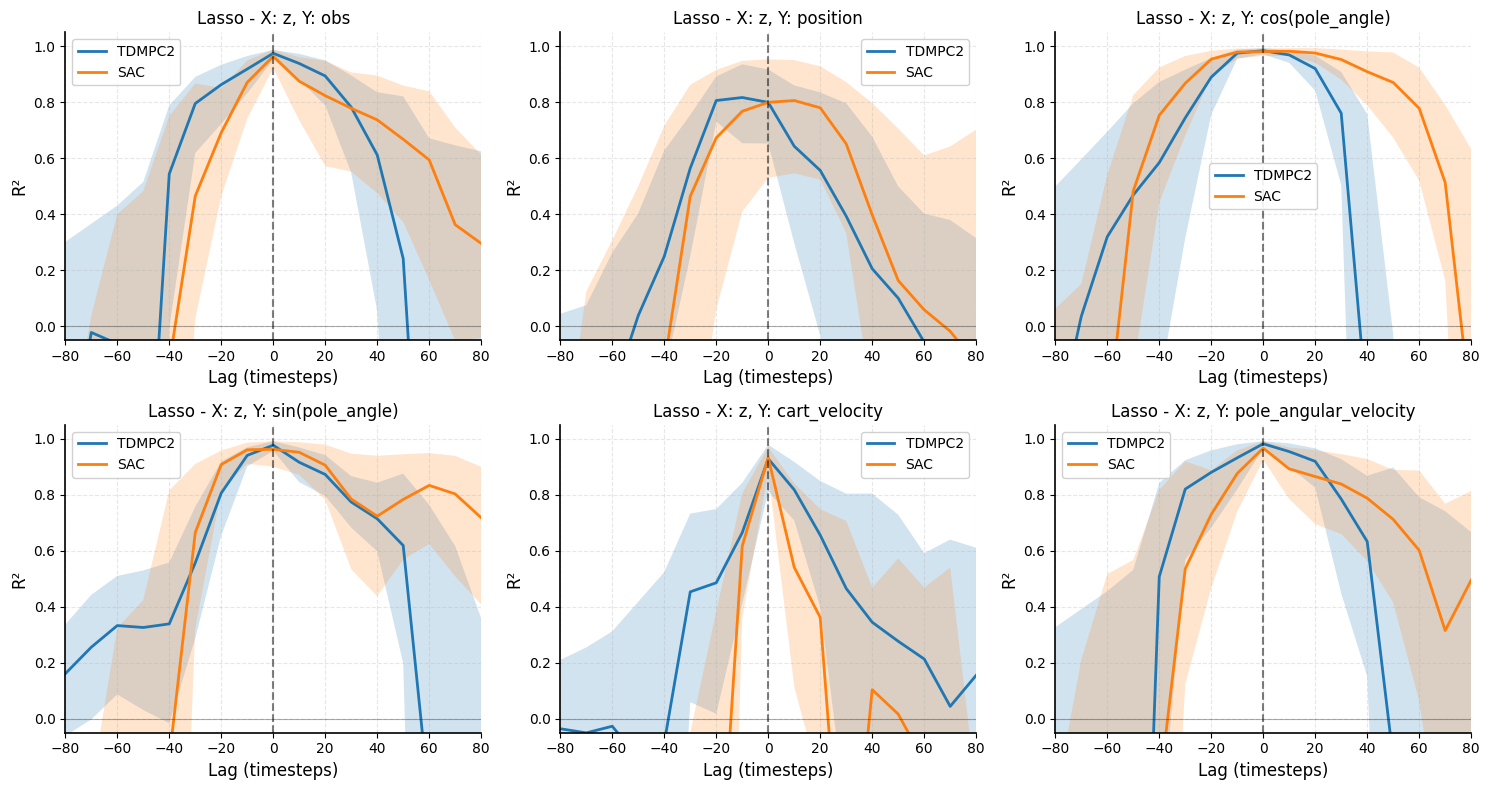

In [56]:
# Create plots comparing SAC vs TDMPC2 for future prediction
plot_keys = [
    ('z', 'obs'),
    ('z', 'position'),
    ('z', 'cos(pole_angle)'),
    ('z', 'sin(pole_angle)'),
    ('z', 'cart_velocity'),
    ('z', 'pole_angular_velocity'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Choose which regression method to use
use_lasso = True  # Set to False for Linear Regression

for idx, (x_var, y_var) in enumerate(plot_keys):
    ax = axes[idx]
    key = f'{x_var}-{y_var}'
    key_auto = f'{y_var}-{y_var}'

    # Select the appropriate results dictionaries based on regression method
    if use_lasso:
        results_tdmpc2 = results_decoding_lasso_tdmpc2_future
        results_sac = results_decoding_lasso_sac_future
        method_name = 'Lasso'
    else:
        results_tdmpc2 = results_decoding_lr_tdmpc2_future
        results_sac = results_decoding_lr_sac_future
        method_name = 'Linear Regression'

    # Plot TDMPC2
    if key in results_tdmpc2:
        results = results_tdmpc2[key]
        results_auto = results_tdmpc2[key_auto]

        r2_mean = results['r2_mean']
        r2_mean_auto = results_auto['r2_mean']
        # r2_mean = {
        #     lag: r2_mean[lag] - r2_mean_auto[lag] for lag in r2_mean.keys()
        # }

        r2_ci = results['r2_ci']
        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags, means, label='TDMPC2', linewidth=2)
        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2)

    # Plot SAC
    if key in results_sac:
        results = results_sac[key]
        results_auto = results_sac[key_auto]

        r2_mean = results['r2_mean']
        r2_mean_auto = results_auto['r2_mean']
        # r2_mean = {
        #     lag: r2_mean[lag] - r2_mean_auto[lag] for lag in r2_mean.keys()
        # }
        r2_ci = results['r2_ci']

        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags, means, label='SAC', linewidth=2)
        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_ylim(-0.05, 1.05)
    #ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-80, 80)
    ax.tick_params(labelsize=10)
    ax.set_title(f'{method_name} - X: {x_var}, Y: {y_var}')

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()
sns.despine()
plt.show()

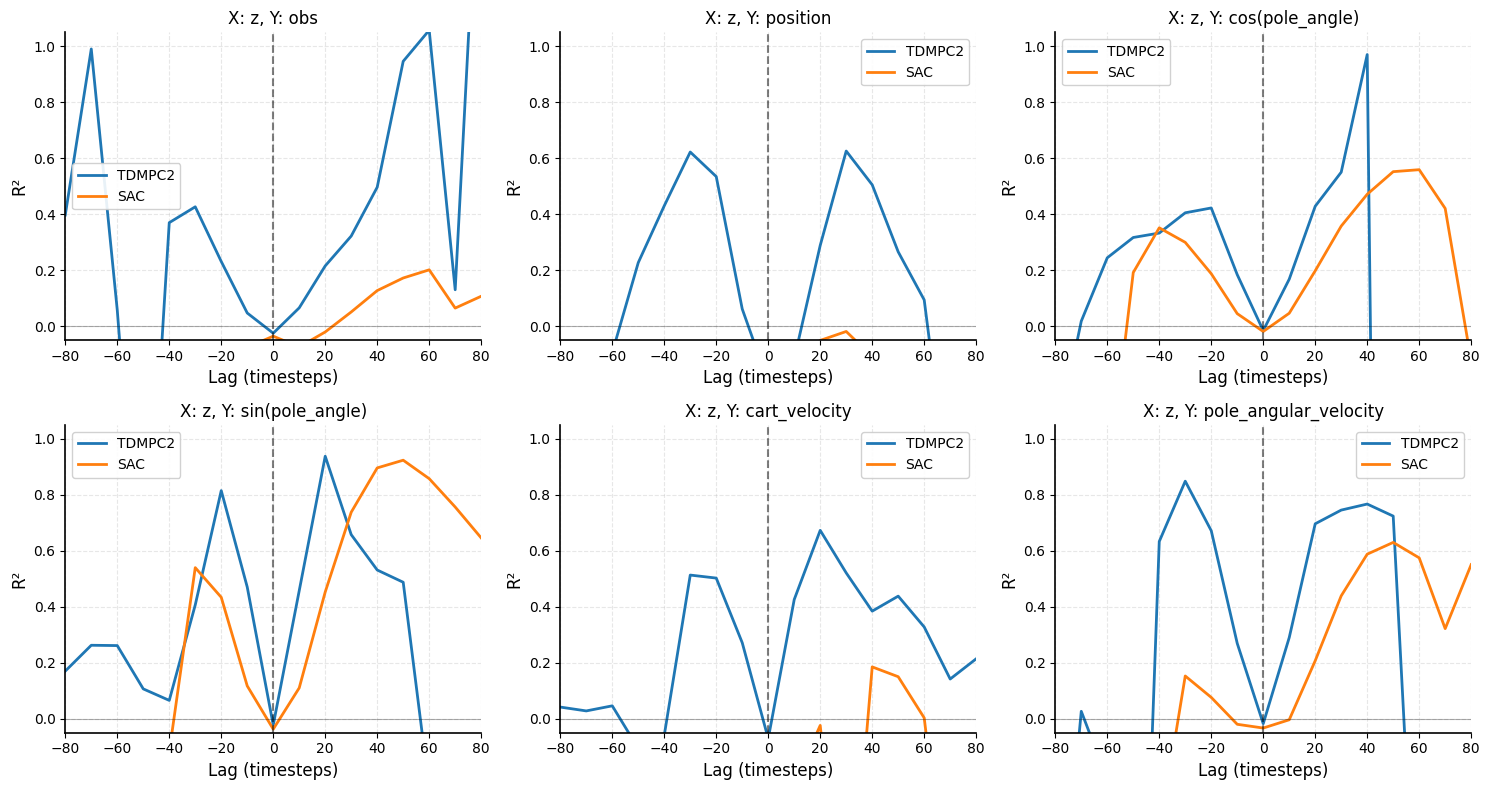

In [50]:
# Create plots comparing SAC vs TDMPC2 for future prediction
plot_keys = [
    ('z', 'obs'),
    ('z', 'position'),
    ('z', 'cos(pole_angle)'),
    ('z', 'sin(pole_angle)'),
    ('z', 'cart_velocity'),
    ('z', 'pole_angular_velocity'),
]

method = 'lasso'  # or 'lasso'
results_tdmpc2 = results_decoding_lr_tdmpc2_future if method == 'linear_regression' else results_decoding_lasso_tdmpc2_future
results_sac = results_decoding_lr_sac_future if method == 'linear_regression' else results_decoding_lasso_sac_future

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (x_var, y_var) in enumerate(plot_keys):
    ax = axes[idx]
    key = f'{x_var}-{y_var}'
    key_auto = f'{y_var}-{y_var}'

    # Plot TDMPC2
    if key in results_tdmpc2:
        results = results_tdmpc2[key]
        results_auto = results_tdmpc2[key_auto]

        r2_mean = results['r2_mean']
        r2_mean_auto = results_auto['r2_mean']
        r2_mean = {
            lag: r2_mean[lag] - r2_mean_auto[lag] for lag in r2_mean.keys()
        }

        r2_ci = results['r2_ci']
        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags, means, label='TDMPC2', linewidth=2)
        #ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2)

    # Plot SAC
    if key in results_sac:
        results = results_sac[key]
        results_auto = results_sac[key_auto]

        r2_mean = results['r2_mean']
        r2_mean_auto = results_auto['r2_mean']
        r2_mean = {
            lag: r2_mean[lag] - r2_mean_auto[lag] for lag in r2_mean.keys()
        }
        r2_ci = results['r2_ci']

        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags, means, label='SAC', linewidth=2)
        #ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_ylim(-0.05, 1.05)
    #ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-80, 80)
    ax.tick_params(labelsize=10)
    ax.set_title(f'X: {x_var}, Y: {y_var}')

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()
sns.despine()
plt.show()

## Difference regression

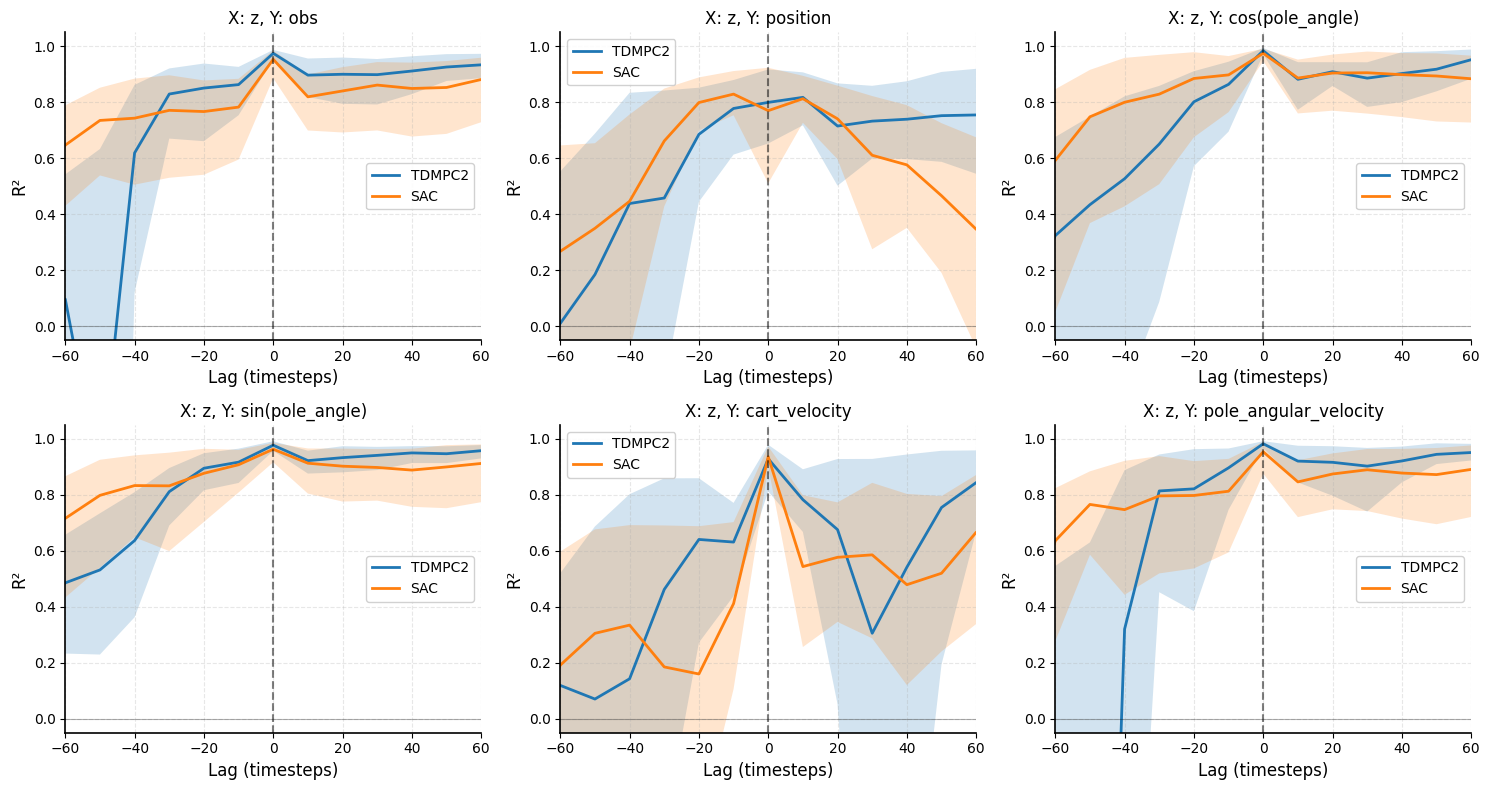

In [35]:
# Create plots comparing SAC vs TDMPC2 for future prediction
plot_keys = [
    ('z', 'obs'),
    ('z', 'position'),
    ('z', 'cos(pole_angle)'),
    ('z', 'sin(pole_angle)'),
    ('z', 'cart_velocity'),
    ('z', 'pole_angular_velocity'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (x_var, y_var) in enumerate(plot_keys):
    ax = axes[idx]
    key = f'{x_var}-{y_var}'
    key_auto = f'{y_var}-{y_var}'

    # Plot TDMPC2
    if key in results_decoding_lasso_tdmpc2_difference:
        results = results_decoding_lasso_tdmpc2_difference[key]
        results_auto = results_decoding_lasso_tdmpc2_difference[key_auto]

        r2_mean = results['r2_mean']
        r2_mean_auto = results_auto['r2_mean']
        # r2_mean = {
        #     lag: r2_mean[lag] - r2_mean_auto[lag] for lag in r2_mean.keys()
        # }

        r2_ci = results['r2_ci']
        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags, means, label='TDMPC2', linewidth=2)
        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2)

    # Plot SAC
    if key in results_decoding_lasso_sac_difference:
        results = results_decoding_lasso_sac_difference[key]
        results_auto = results_decoding_lasso_sac_difference[key_auto]

        r2_mean = results['r2_mean']
        r2_mean_auto = results_auto['r2_mean']
        # r2_mean = {
        #     lag: r2_mean[lag] - r2_mean_auto[lag] for lag in r2_mean.keys()
        # }
        r2_ci = results['r2_ci']

        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags, means, label='SAC', linewidth=2)
        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_ylim(-0.05, 1.05)
    #ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-60, 60)
    ax.tick_params(labelsize=10)
    ax.set_title(f'X: {x_var}, Y: {y_var}')

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()
sns.despine()
plt.show()

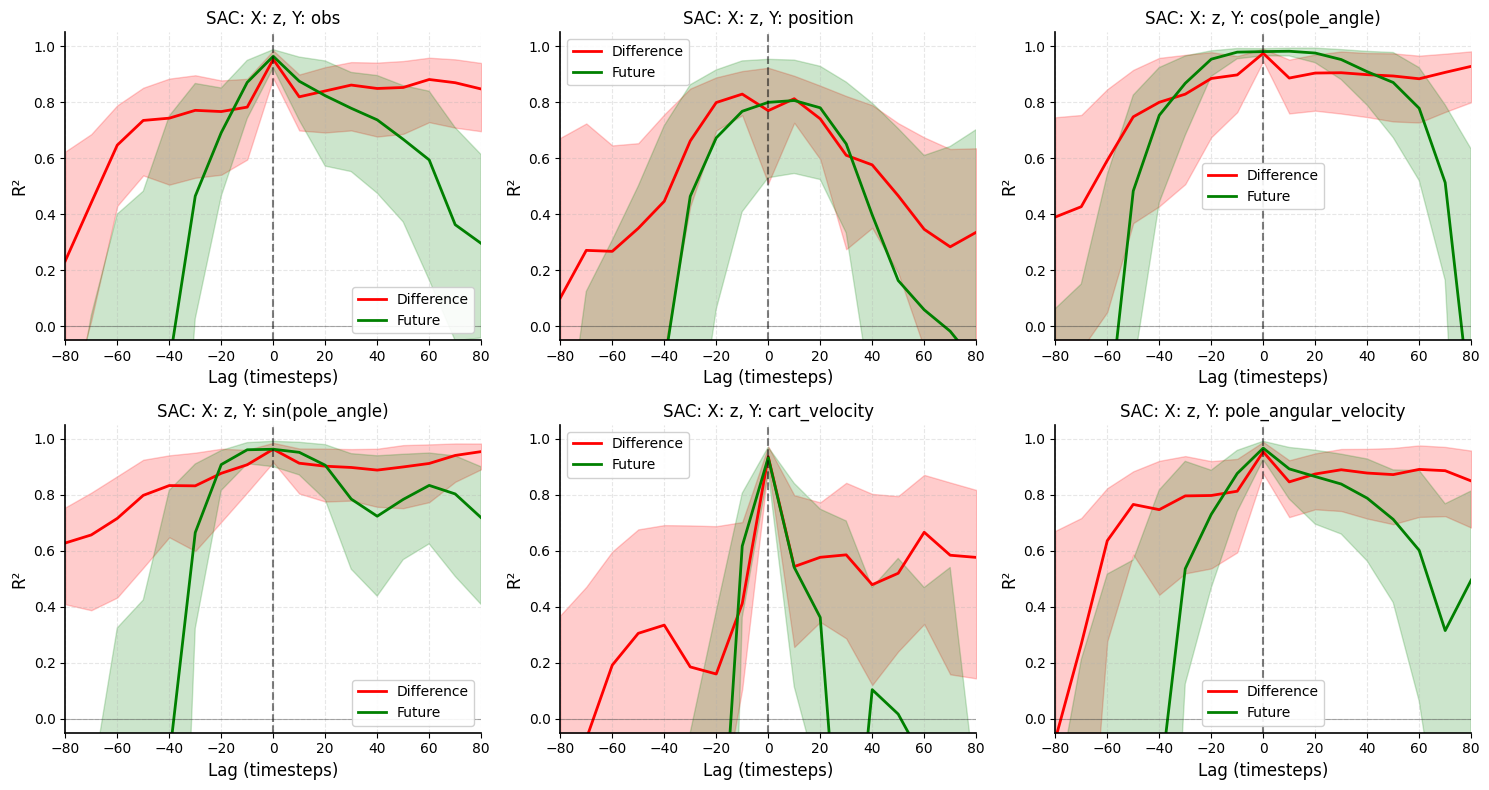

In [67]:
# Create plots comparing difference vs future prediction
plot_keys = [
    ('z', 'obs'),
    ('z', 'position'),
    ('z', 'cos(pole_angle)'),
    ('z', 'sin(pole_angle)'),
    ('z', 'cart_velocity'),
    ('z', 'pole_angular_velocity'),
]

# Choose which model to plot: 'tdmpc2' or 'sac'
model_type = 'sac'  # or 'sac'
decoder_type = 'lasso'  # or 'lasso'

if model_type == 'tdmpc2':
    if decoder_type == 'lasso':
        results_difference = results_decoding_lasso_tdmpc2_difference
        results_future = results_decoding_lasso_tdmpc2_future
    else:  # 'lr'
        results_difference = results_decoding_lr_tdmpc2_difference
        results_future = results_decoding_lr_tdmpc2_future
else:  # 'sac'
    if decoder_type == 'lasso':
        results_difference = results_decoding_lasso_sac_difference
        results_future = results_decoding_lasso_sac_future
    else:  # 'lr'
        results_difference = results_decoding_lr_sac_difference
        results_future = results_decoding_lr_sac_future

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (x_var, y_var) in enumerate(plot_keys):
    ax = axes[idx]
    key = f'{x_var}-{y_var}'
    key_auto = f'{y_var}-{y_var}'

    # Plot difference
    if key in results_difference:
        results = results_difference[key]
        results_auto = results_difference[key_auto]

        r2_mean = results['r2_mean']
        r2_mean_auto = results_auto['r2_mean']
        # r2_mean = {
        #     lag: r2_mean[lag] - r2_mean_auto[lag] for lag in r2_mean.keys()
        # }

        r2_ci = results['r2_ci']
        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags, means, label='Difference', linewidth=2, color='red')
        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2, color='red')

    # Plot future
    if key in results_future:
        results = results_future[key]
        results_auto = results_future[key_auto]

        r2_mean = results['r2_mean']
        r2_mean_auto = results_auto['r2_mean']
        # r2_mean = {
        #     lag: r2_mean[lag] - r2_mean_auto[lag] for lag in r2_mean.keys()
        # }
        r2_ci = results['r2_ci']

        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags, means, label='Future', linewidth=2, color='green')
        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2, color='green')

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_ylim(-0.05, 1.05)
    #ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-80, 80)
    ax.tick_params(labelsize=10)
    ax.set_title(f'{model_type.upper()}: X: {x_var}, Y: {y_var}')

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()
sns.despine()
plt.show()

## Compare auto-correlation

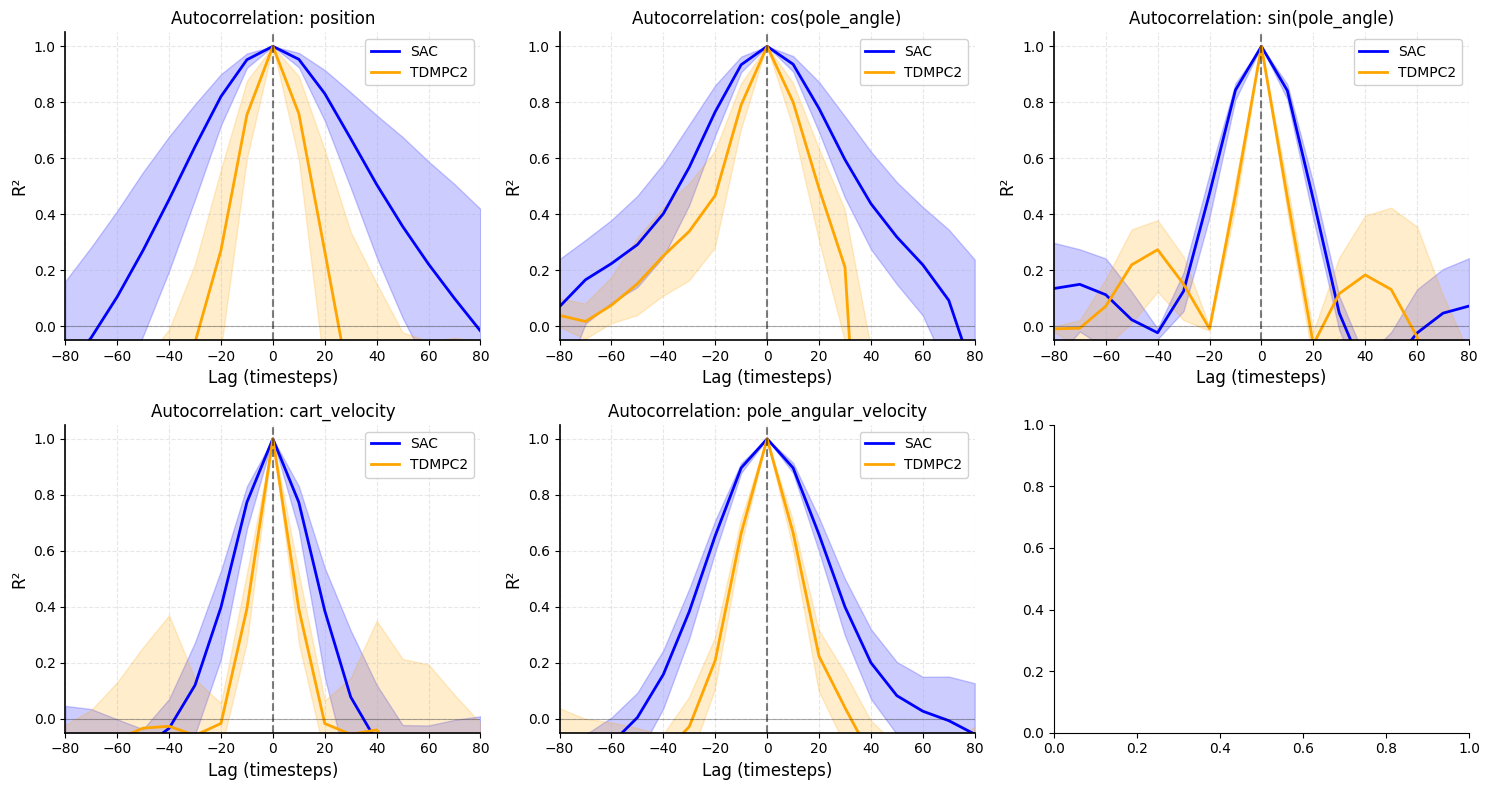

In [73]:
# Compare autocorrelation between SAC and TDMPC2
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

state_vars = [
    'position',
    'cos(pole_angle)',
    'sin(pole_angle)',
    'cart_velocity',
    'pole_angular_velocity',
]

for idx, var in enumerate(state_vars):
    ax = axes[idx]

    # Plot SAC autocorrelation
    key_sac = f"{var}-{var}"
    if key_sac in results_decoding_lasso_sac_future:
        results = results_decoding_lasso_sac_future[key_sac]
        r2_mean = results['r2_mean']
        r2_ci = results['r2_ci']

        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags, means, label='SAC', linewidth=2, color='blue')
        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2, color='blue')

    # Plot TDMPC2 autocorrelation
    key_tdmpc2 = f"{var}-{var}"
    if key_tdmpc2 in results_decoding_lasso_tdmpc2_future:
        results = results_decoding_lasso_tdmpc2_future[key_tdmpc2]
        r2_mean = results['r2_mean']
        r2_ci = results['r2_ci']

        lags = list(r2_mean.keys())
        means = list(r2_mean.values())
        ci_lower = [r2_ci[lag][0] for lag in lags]
        ci_upper = [r2_ci[lag][1] for lag in lags]

        ax.plot(lags, means, label='TDMPC2', linewidth=2, color='orange')
        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2, color='orange')

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-80, 80)
    ax.tick_params(labelsize=10)
    ax.set_title(f'Autocorrelation: {var}')

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()
sns.despine()
plt.show()


In [71]:
results_decoding_lasso_tdmpc2_future.keys()

dict_keys(['z-obs', 'z-position', 'z-cos(pole_angle)', 'z-sin(pole_angle)', 'z-cart_velocity', 'z-pole_angular_velocity', 'z-rewards', 'z-actions', 'obs-obs', 'position-position', 'cos(pole_angle)-cos(pole_angle)', 'sin(pole_angle)-sin(pole_angle)', 'cart_velocity-cart_velocity', 'pole_angular_velocity-pole_angular_velocity', 'rewards-rewards', 'actions-actions'])